Write a function which finds and prints the mid-point coordinates of a line. The function should take in four parameters (x1, y1, x2, y2). The midpoint formula for two points (x1, y1) and (x2, y2) is:

$$ (\frac{x_{1}+x_{2}}{2}),(\frac{y_{1}+y_{2}}{2}) $$

Concept of Technologies and AI

• Define the function with the four parameters.
• Calculate the midpoint using the formula above.
• Print the result.

In [1]:
import matplotlib.pyplot as plt


def _plot_step(points, lines=None, title="", xlim=None, ylim=None):
    """Draw one step of the midpoint construction: labelled points plus optional lines."""
    fig, ax = plt.subplots(figsize=(5, 5))

    for x, y, label, color in points:
        ax.scatter(x, y, color=color, s=90, zorder=3)
        ax.annotate(f"{label} ({x}, {y})", (x, y), textcoords="offset points", xytext=(8, 8))

    for x_vals, y_vals, style, color in lines or []:
        ax.plot(x_vals, y_vals, style, color=color, zorder=2)

    ax.axhline(0, color="gray", linewidth=0.5)
    ax.axvline(0, color="gray", linewidth=0.5)
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    if xlim:
        ax.set_xlim(xlim)
    if ylim:
        ax.set_ylim(ylim)
    ax.set_aspect("equal", adjustable="box")
    plt.show()

In [2]:
def find_midpoint(x1, y1, x2, y2):
    """Find and print the midpoint of the line AB, step by step, with a graph per step."""

    margin = max(abs(x1 - x2), abs(y1 - y2), 1) * 0.5 + 1
    xlim = (min(x1, x2) - margin, max(x1, x2) + margin)
    ylim = (min(y1, y2) - margin, max(y1, y2) + margin)

    # Step 1: plot the two endpoints
    print("Step 1: Plot the two endpoints of the line.")
    print(f"  A = ({x1}, {y1})")
    print(f"  B = ({x2}, {y2})")
    _plot_step(
        [(x1, y1, "A", "tab:blue"), (x2, y2, "B", "tab:red")],
        title="Step 1: The two endpoints",
        xlim=xlim, ylim=ylim,
    )

    # Step 2: draw the line segment joining them
    print("\nStep 2: Draw the line segment AB.")
    _plot_step(
        [(x1, y1, "A", "tab:blue"), (x2, y2, "B", "tab:red")],
        lines=[([x1, x2], [y1, y2], "--", "gray")],
        title="Step 2: Line segment AB",
        xlim=xlim, ylim=ylim,
    )

    # Step 3: sum the x-coordinates and the y-coordinates
    x_sum = x1 + x2
    y_sum = y1 + y2
    print("\nStep 3: Sum the x-coordinates and the y-coordinates.")
    print(f"  x1 + x2 = {x1} + {x2} = {x_sum}")
    print(f"  y1 + y2 = {y1} + {y2} = {y_sum}")

    # Step 4: divide each sum by 2 to get the midpoint
    mid_x = x_sum / 2
    mid_y = y_sum / 2
    print("\nStep 4: Divide each sum by 2 to get the midpoint coordinates.")
    print(f"  mid_x = {x_sum} / 2 = {mid_x}")
    print(f"  mid_y = {y_sum} / 2 = {mid_y}")
    _plot_step(
        [(x1, y1, "A", "tab:blue"), (x2, y2, "B", "tab:red"), (mid_x, mid_y, "M", "tab:green")],
        lines=[([x1, x2], [y1, y2], "--", "gray")],
        title="Step 4: Midpoint M plotted on AB",
        xlim=xlim, ylim=ylim,
    )

    # Step 5: final result
    print("\nStep 5: Result")
    print(f"  Midpoint of AB = ({mid_x}, {mid_y})")

    return mid_x, mid_y

Step 1: Plot the two endpoints of the line.
  A = (1, 2)
  B = (7, 8)


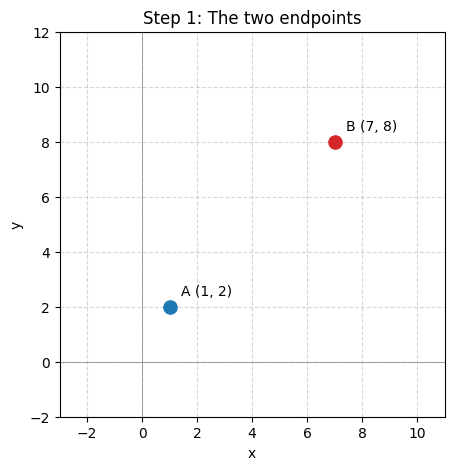


Step 2: Draw the line segment AB.


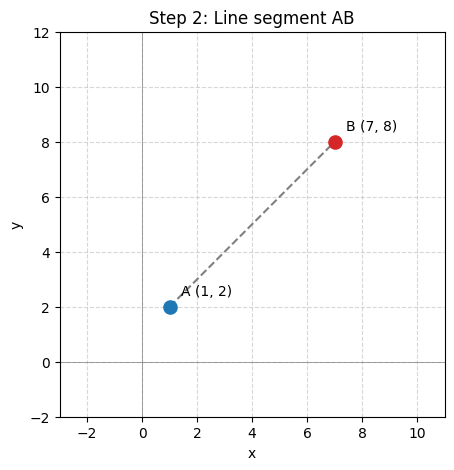


Step 3: Sum the x-coordinates and the y-coordinates.
  x1 + x2 = 1 + 7 = 8
  y1 + y2 = 2 + 8 = 10

Step 4: Divide each sum by 2 to get the midpoint coordinates.
  mid_x = 8 / 2 = 4.0
  mid_y = 10 / 2 = 5.0


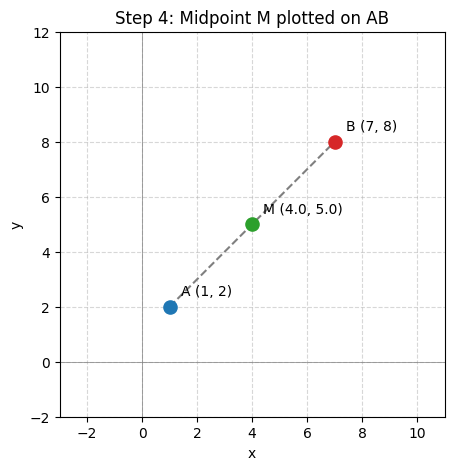


Step 5: Result
  Midpoint of AB = (4.0, 5.0)


(4.0, 5.0)

In [3]:
# Example usage
find_midpoint(1, 2, 7, 8)

Write a function which takes one integer (n) as a parameter. Your function should then print out all triangular numbers from 1 up to the nth term.

Triangular numbers are given by the formula:

$$ T_n = \frac{n(n + 1)}{2} $$

- Iterate through numbers from 1 to n.
- Use the formula to calculate each triangular number.
- Print each result.

In [4]:
import matplotlib.pyplot as plt


def _plot_triangle_step(i, t_i):
    """Draw T_i dots arranged in i rows, illustrating why T_i is 'triangular'."""
    fig, ax = plt.subplots(figsize=(4, 4))

    for row in range(1, i + 1):
        y = -row
        x_offset = -(row - 1) / 2
        for col in range(row):
            ax.scatter(x_offset + col, y, s=120, color="tab:blue", zorder=3)

    ax.set_title(f"T_{i} = {t_i} dots in {i} row(s)")
    ax.set_xlim(-i / 2 - 1, i / 2 + 1)
    ax.set_ylim(-i - 1, 0)
    ax.set_aspect("equal")
    ax.axis("off")
    plt.show()


def _plot_bar_step(values, n):
    """Bar chart of the triangular numbers computed so far."""
    fig, ax = plt.subplots(figsize=(5, 3))
    idx = range(1, len(values) + 1)

    ax.bar(idx, values, color="tab:green")
    for x, v in zip(idx, values):
        ax.text(x, v, str(v), ha="center", va="bottom")

    ax.set_xticks(range(1, n + 1))
    ax.set_xlabel("n")
    ax.set_ylabel("T_n")
    ax.set_title("Triangular numbers so far")
    plt.show()

In [5]:
def print_triangular_numbers(n):
    """Print and plot every triangular number from T_1 to T_n, step by step."""

    values = []
    for i in range(1, n + 1):
        t_i = i * (i + 1) // 2
        values.append(t_i)

        print(f"Step {i}: T_{i} = {i}({i} + 1) / 2 = {i * (i + 1)} / 2 = {t_i}")
        _plot_triangle_step(i, t_i)
        _plot_bar_step(values, n)
        print()

    print(f"Result: triangular numbers from T_1 to T_{n} = {values}")
    return values

Step 1: T_1 = 1(1 + 1) / 2 = 2 / 2 = 1


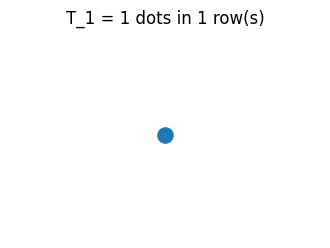

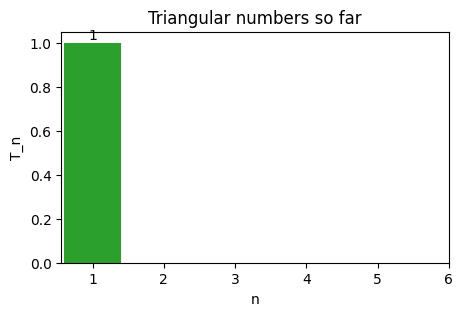


Step 2: T_2 = 2(2 + 1) / 2 = 6 / 2 = 3


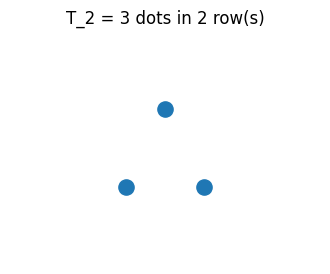

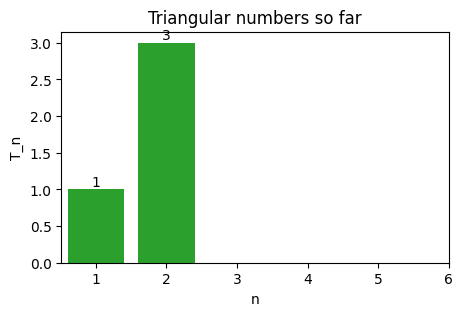


Step 3: T_3 = 3(3 + 1) / 2 = 12 / 2 = 6


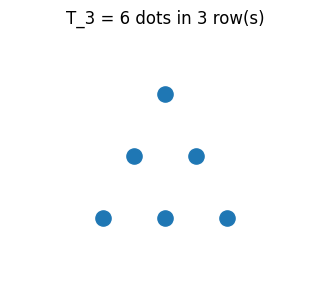

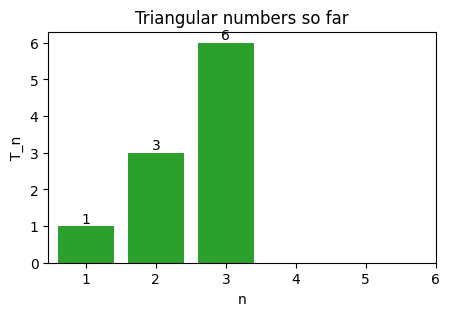


Step 4: T_4 = 4(4 + 1) / 2 = 20 / 2 = 10


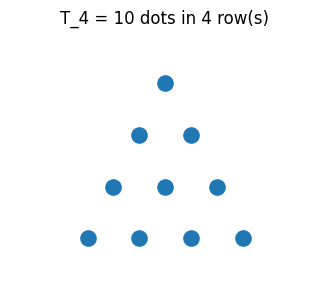

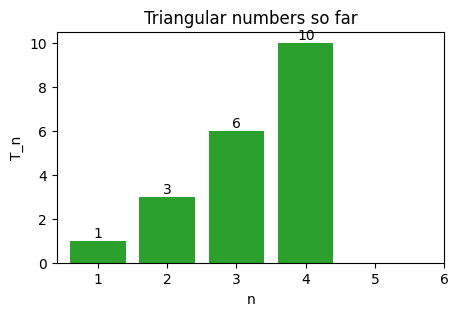


Step 5: T_5 = 5(5 + 1) / 2 = 30 / 2 = 15


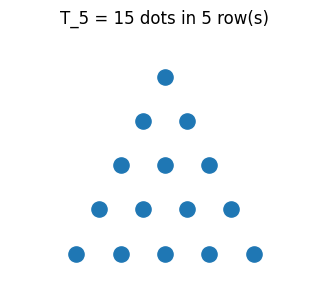

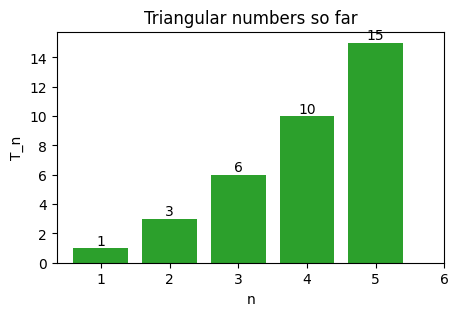


Step 6: T_6 = 6(6 + 1) / 2 = 42 / 2 = 21


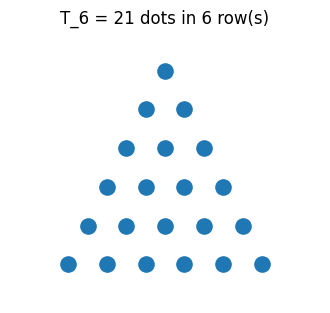

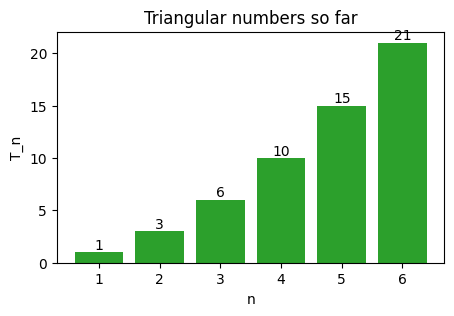


Result: triangular numbers from T_1 to T_6 = [1, 3, 6, 10, 15, 21]


[1, 3, 6, 10, 15, 21]

In [6]:
# Example usage
print_triangular_numbers(6)

Write a void function which solves quadratics. Your program will take three parameters. E.g. function (a, b, c). By solving quadratic equations, you are finding where the curve crosses the x axis. There are some equations which have 2, 1 or no roots at all. Your program should cater for all scenarios. The letters used in the function uses a, b and c as parameters.

For a quadratic equation:

$$ x = \frac{-b \pm \sqrt{b^2 - 4ac}}{2a} $$

You'll need to:

- Calculate the discriminant:
$$ \Delta = b^2 - 4ac $$

- Use the discriminant to determine the nature of the roots:
    - If D >0, two distinct roots.
    - If D = 0, one repeated root.
    - If D < 0, no real roots.
    -  Print the roots accordingly.

In [7]:
import numpy as np
import matplotlib.pyplot as plt


def _plot_quadratic(a, b, c, roots=None, title=""):
    """Plot y = ax^2 + bx + c, marking any real roots on the x-axis."""
    vertex_x = -b / (2 * a)
    span = 5
    if roots:
        span = max(span, max(abs(r - vertex_x) for r in roots) * 1.8 + 1)

    x = np.linspace(vertex_x - span, vertex_x + span, 400)
    y = a * x**2 + b * x + c

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(x, y, color="tab:blue", label=f"y = {a}x² + {b}x + {c}")
    ax.axhline(0, color="gray", linewidth=0.8)
    ax.axvline(0, color="gray", linewidth=0.8)

    if roots:
        for r in roots:
            ax.scatter(r, 0, color="tab:red", s=90, zorder=3)
            ax.annotate(f"x = {r:.3g}", (r, 0), textcoords="offset points", xytext=(0, 10), ha="center")

    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.legend()
    plt.show()

In [8]:
def solve_quadratic(a, b, c):
    """Solve ax^2 + bx + c = 0 step by step, printing and plotting each stage. Void: prints only."""

    if a == 0:
        print("a must not be 0 for the equation to be quadratic.")
        return

    # Step 1: show the equation and its curve
    print(f"Step 1: The equation is {a}x^2 + {b}x + {c} = 0.")
    _plot_quadratic(a, b, c, title="Step 1: The quadratic curve")

    # Step 2: calculate the discriminant
    discriminant = b**2 - 4 * a * c
    print("\nStep 2: Calculate the discriminant.")
    print(f"  D = b^2 - 4ac = {b}^2 - 4({a})({c}) = {b**2} - {4 * a * c} = {discriminant}")

    # Step 3 & 4: determine the nature of the roots, solve, and plot
    print("\nStep 3: Determine the nature of the roots.")
    if discriminant > 0:
        print("  D > 0, so there are two distinct real roots.")
        sqrt_d = discriminant**0.5
        x1 = (-b + sqrt_d) / (2 * a)
        x2 = (-b - sqrt_d) / (2 * a)

        print("\nStep 4: Apply the quadratic formula.")
        print(f"  x1 = (-{b} + sqrt({discriminant})) / (2 * {a}) = {x1}")
        print(f"  x2 = (-{b} - sqrt({discriminant})) / (2 * {a}) = {x2}")
        _plot_quadratic(a, b, c, roots=[x1, x2], title="Step 4: Two distinct roots")
        print(f"\nResult: the curve crosses the x-axis at x = {x1} and x = {x2}.")

    elif discriminant == 0:
        print("  D = 0, so there is one repeated real root.")
        x1 = -b / (2 * a)

        print("\nStep 4: Apply the quadratic formula.")
        print(f"  x = -{b} / (2 * {a}) = {x1}")
        _plot_quadratic(a, b, c, roots=[x1], title="Step 4: One repeated root")
        print(f"\nResult: the curve touches the x-axis at x = {x1}.")

    else:
        print("  D < 0, so there are no real roots.")
        print("\nStep 4: The curve never crosses the x-axis.")
        _plot_quadratic(a, b, c, title="Step 4: No real roots")
        print("\nResult: no real roots -- the curve stays entirely above or below the x-axis.")

=== Two distinct roots ===
Step 1: The equation is 1x^2 + -3x + 2 = 0.


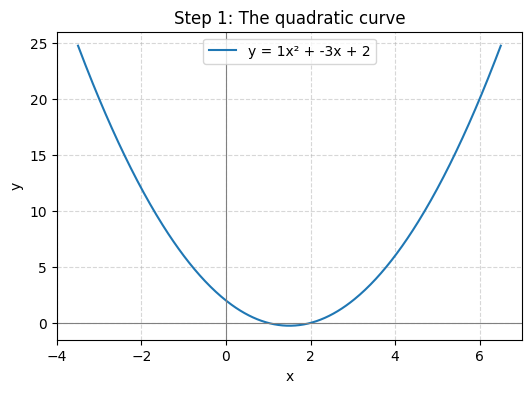


Step 2: Calculate the discriminant.
  D = b^2 - 4ac = -3^2 - 4(1)(2) = 9 - 8 = 1

Step 3: Determine the nature of the roots.
  D > 0, so there are two distinct real roots.

Step 4: Apply the quadratic formula.
  x1 = (--3 + sqrt(1)) / (2 * 1) = 2.0
  x2 = (--3 - sqrt(1)) / (2 * 1) = 1.0


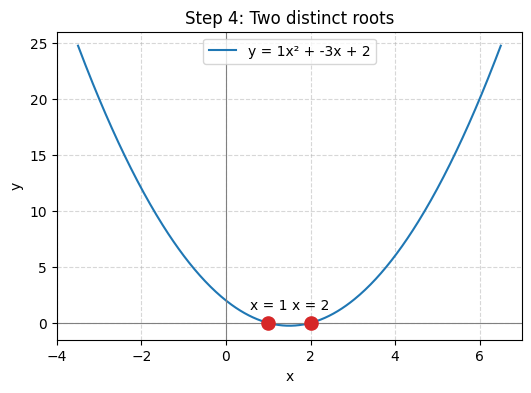


Result: the curve crosses the x-axis at x = 2.0 and x = 1.0.

=== One repeated root ===
Step 1: The equation is 1x^2 + -2x + 1 = 0.


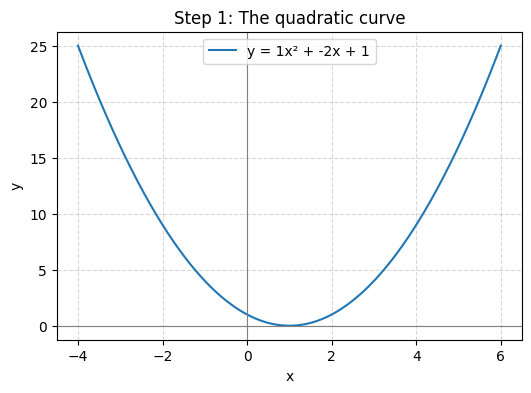


Step 2: Calculate the discriminant.
  D = b^2 - 4ac = -2^2 - 4(1)(1) = 4 - 4 = 0

Step 3: Determine the nature of the roots.
  D = 0, so there is one repeated real root.

Step 4: Apply the quadratic formula.
  x = --2 / (2 * 1) = 1.0


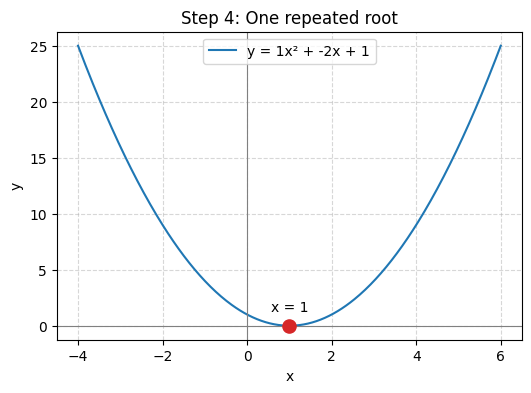


Result: the curve touches the x-axis at x = 1.0.

=== No real roots ===
Step 1: The equation is 1x^2 + 0x + 1 = 0.


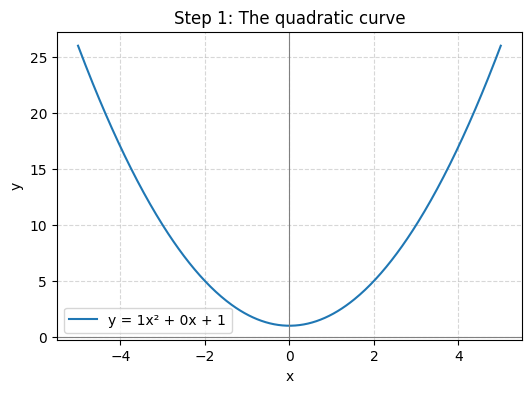


Step 2: Calculate the discriminant.
  D = b^2 - 4ac = 0^2 - 4(1)(1) = 0 - 4 = -4

Step 3: Determine the nature of the roots.
  D < 0, so there are no real roots.

Step 4: The curve never crosses the x-axis.


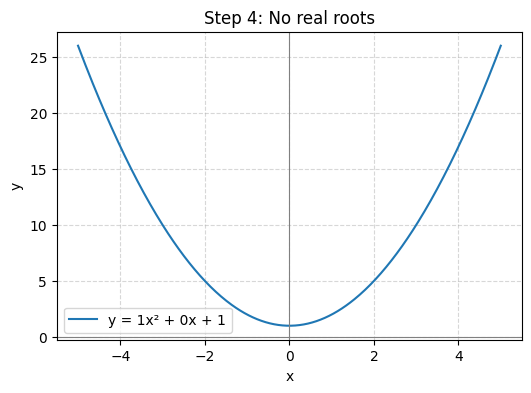


Result: no real roots -- the curve stays entirely above or below the x-axis.


In [9]:
# Example usage: covers all three scenarios

print("=== Two distinct roots ===")
solve_quadratic(1, -3, 2)

print("\n=== One repeated root ===")
solve_quadratic(1, -2, 1)

print("\n=== No real roots ===")
solve_quadratic(1, 0, 1)